# TPM034A Machine Learning for socio-technical systems 
## `Lab session 05: Explainable AI of a classification model for appliance usage prediction`

**Delft University of Technology**<br>
**Q2 2025**<br>
**Instructor:** Giacomo Marangoni <br>

## `Instructions`

**Lab sessions aim to:**<br>
* Show and reinforce how models and ideas presented in class are used in practice.<br>
* Help you gather hands-on machine learning skills.<br>

**Lab sessions are:**<br>
* Learning environments where you work with Jupyter notebooks and where you can get support from TAs and fellow students.<br> 
* Not graded and do not have to be submitted. 

### `Use of AI tools`
AI tools, such as ChatGPT and Co-pilot, are great tools to assist with programming. Moreover, in your later careers you will work in a world where such tools are widely available. As such, we **encourage** you to use AI tools **effectively** (both in the lab sessions and assignments). However, be careful not to overestimate the capacity of AI tools! AI tools cannot replace you: you still have to conceptualise the problem, dissect it and structure it, to conduct proper analysis and modelling. We recommend being especially **reticent** with using AI tools for the more conceptual and reflective oriented questions. 

### `Google Colab workspace set-up`

Uncomment the following cells code lines if you are running this notebook on Colab

In [34]:
#!git clone https://github.com/TPM034A/Q2_2025
#!pip install -r Q2_2025/requirements_colab.txt
#!mv "/content/Q2_2025/Lab_sessions/lab_session_05/data" /content/data

# `Application: Explainable AI of a classification model for appliance usage prediction` <br>

#### **Introduction**

In this notebook you are going to train and explain a Random Forest Classifier model to predict the probability of using a given appliance in the next 24 hours.

#### **Data**

1. `data/devices.pkl`: A pickle file with a pandas.DataFrame of Wh hourly energy consumption by appliance within a household of the REFIT dataset, over a period of about two years.
2. `data/devices.pkl`: A pickle file with a pandas.DataFrame of normalized weather variables: `dwpt` is Dew Point (related to moisture), `rhum` is relative humidity, `temp` is temperature, `wdir` is wind direction, `wspd` is wind speed.
3. `data/price.pkl`: A pickle file with a pandas.Series with electricity day-ahead prices in GBP/MWh.


**Learning objectives**. After completing the following exercises you will be able to: <br>

- prepare and explore appliance-level smart meter data for training a ML model to predict whether an appliance will be used or not at a given hour;
- use XAI tools to gain insights on usage behaviour;
- reflect on practical and ethical implications.

### Data preparation

In [35]:
# Load 'data/devices.pkl', 'data/weather.pkl' and 'data/price.pkl'.
# Weather is the same as in the lab session.
# Devices contains Wh consumed by given devices at each timestamp.
# Price contains electricity prices for each timestamp.

In [36]:
import pandas as pd
devices = pd.read_pickle('data/devices.pkl')
weather = pd.read_pickle('data/weather.pkl')
price = pd.read_pickle('data/price.pkl')

In [37]:
# Add a colum "Load" to devices as the sum of all appliances consumption

In [38]:
devices['Load'] = devices.sum(axis=1)
devices.head()

,Toaster,Fridge-Freezer,Freezer,Tumble Dryer,Dishwasher,Washing Machine,Television,Microwave,Kettle,Load
Time,,,,,,,,,,
2013-09-25 19:00:00,0.0,28.381963,37.084881,0.0,0.0,0.0,144.262599,0.0,0.0,209.729443
2013-09-25 20:00:00,0.0,50.966044,44.848896,0.0,0.0,0.0,143.933786,0.0,0.0,239.748727
2013-09-25 21:00:00,0.0,31.829103,36.810491,0.0,0.0,0.0,68.949239,0.0,0.0,137.588832
2013-09-25 22:00:00,0.0,34.850258,36.289157,0.0,0.0,0.0,0.000000,0.0,0.0,71.139415
2013-09-25 23:00:00,0.0,50.380546,36.912969,0.0,0.0,0.0,0.000000,0.0,0.0,87.293515


In [39]:
# Merge all the datasets in one dataframe

In [40]:
df = devices.join([weather, price])
df.head()

,Toaster,Fridge-Freezer,Freezer,Tumble Dryer,Dishwasher,Washing Machine,Television,Microwave,Kettle,Load,dwpt,rhum,temp,wdir,wspd,price
Time,,,,,,,,,,,,,,,,
2013-09-25 19:00:00,0.0,28.381963,37.084881,0.0,0.0,0.0,144.262599,0.0,0.0,209.729443,0.62500,0.774074,0.833333,0.114286,0.123684,53.49
2013-09-25 20:00:00,0.0,50.966044,44.848896,0.0,0.0,0.0,143.933786,0.0,0.0,239.748727,0.62500,0.733333,0.750000,0.085714,0.100000,41.51
2013-09-25 21:00:00,0.0,31.829103,36.810491,0.0,0.0,0.0,68.949239,0.0,0.0,137.588832,0.59375,0.737037,0.833333,0.057143,0.171053,40.06
2013-09-25 22:00:00,0.0,34.850258,36.289157,0.0,0.0,0.0,0.000000,0.0,0.0,71.139415,0.59375,0.737037,0.833333,0.171429,0.242105,42.06
2013-09-25 23:00:00,0.0,50.380546,36.912969,0.0,0.0,0.0,0.000000,0.0,0.0,87.293515,0.53125,0.703704,0.916667,0.142857,0.269737,37.91


In [41]:
# Consider zeros in temperature ("temp" column) as NAs, and interpolate the resulting missing values linearly

In [42]:
import numpy as np
df.loc[np.isclose(df['temp'], 0),'temp'] = np.nan
df['temp'] = df['temp'].interpolate()

### Data exploration

In [43]:
# Plot NAs count per day over the whole time range. Are there any evident missing periods?

# Hint: use isna(), groupby(), index.date and sum()

<Axes: >

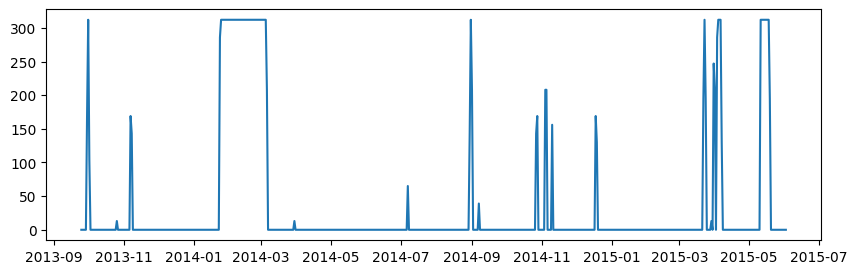

In [44]:
nas = df.isna().groupby(df.index.date).sum().sum(axis=1)
nas.plot(figsize=(10,3))

In [45]:
# 2014-01-24 to 2014-03-06 and 2015-03-31 to 2015-05-19
with pd.option_context('display.max_rows', None):
    print(nas[nas>0])

2013-09-30    169
2013-10-01    312
2013-10-02    104
2013-10-26     13
2013-11-07    169
2013-11-08    143
2014-01-24    286
2014-01-25    312
2014-01-26    312
2014-01-27    312
2014-01-28    312
2014-01-29    312
2014-01-30    312
2014-01-31    312
2014-02-01    312
2014-02-02    312
2014-02-03    312
2014-02-04    312
2014-02-05    312
2014-02-06    312
2014-02-07    312
2014-02-08    312
2014-02-09    312
2014-02-10    312
2014-02-11    312
2014-02-12    312
2014-02-13    312
2014-02-14    312
2014-02-15    312
2014-02-16    312
2014-02-17    312
2014-02-18    312
2014-02-19    312
2014-02-20    312
2014-02-21    312
2014-02-22    312
2014-02-23    312
2014-02-24    312
2014-02-25    312
2014-02-26    312
2014-02-27    312
2014-02-28    312
2014-03-01    312
2014-03-02    312
2014-03-03    312
2014-03-04    312
2014-03-05    312
2014-03-06    208
2014-03-30     13
2014-07-07     65
2014-08-30    143
2014-08-31    312
2014-09-01    208
2014-09-07     39
2014-10-27    143
2014-10-28

In [46]:
# In 1 year, from 2014-03-10 to 2015-03-09, which appliance cumulatively consumed the most energy?

In [47]:
devices_list = ['Toaster', 'Fridge-Freezer', 'Freezer',
       'Tumble Dryer', 'Dishwasher', 'Washing Machine', 'Television',
       'Microwave', 'Kettle']
consumption = df.loc['2014-03-10':'2015-03-09', devices_list].sum(axis=0)
consumption.sort_values(ascending=False)

Tumble Dryer       505356.427797
Fridge-Freezer     455838.669621
Television         384867.378416
Freezer            314609.803823
Kettle             175712.562858
Washing Machine    111990.426656
Dishwasher          87107.575471
Toaster             17101.149235
Microwave            2920.029016
dtype: float64

In [48]:
# Which appliance was turned on for the highest number of hours (i.e. consumption > 1Wh)?

In [49]:
usage = (df.loc['2014-03-10':'2015-03-09', devices_list] > 1).astype(int)
usage_sum = usage.sum(axis=0)
usage_sum.sort_values(ascending=False)

Freezer            8197
Fridge-Freezer     7806
Television         3670
Kettle             2026
Washing Machine    1032
Tumble Dryer        865
Dishwasher          749
Microwave           428
Toaster             300
dtype: int64

In [50]:
# Which appliance consumes per hour the highest?

In [51]:
consumption.div(usage_sum).sort_values(ascending=False)

Tumble Dryer       584.227084
Dishwasher         116.298499
Washing Machine    108.517855
Television         104.868495
Kettle              86.728807
Fridge-Freezer      58.395935
Toaster             57.003831
Freezer             38.381091
Microwave            6.822498
dtype: float64

In [52]:
# Plot the fraction of days (y-axis) in the given year by which each appliance (color) is used for each hour (x-axis)

<Axes: xlabel='Time'>

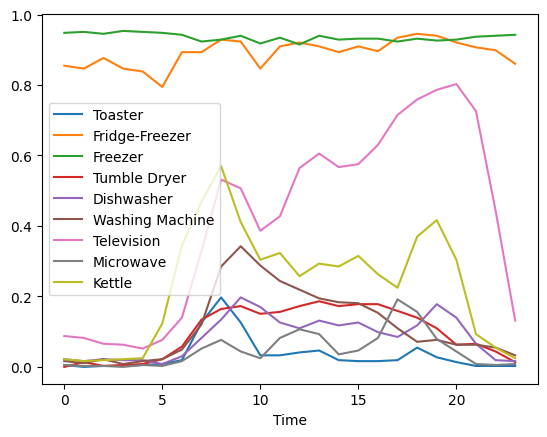

In [53]:
usage.groupby(usage.index.hour).mean().plot()

### Model training

In [54]:
# Prepare train and test datasets with the following characteristics:
# Train data period: from 2014-03-10 to 2015-03-09
# Test data period: 2015-03-10
# y feature: usage of television (i.e. consumption > 1)
# X features:
# - hour (int)
# - weekday (int)
# - weather variables
# - usage 24h before (1 if television was used at the same hour the day before)
# - activity 24h before (1 if any appliance was used at the same hour the day before)
# - usage yesterday (1 if television was used at least 1 hour during the whole day before)
# - price
# Drop NAs

# Hint for computing "usage yesterday": group usage by date, take the max, shift, then reindex to hourly using forward fill 

In [55]:
df2 = df.dropna()
appliance = 'Television'
df3 = df2.join((df2[appliance]>1).groupby(df2.index.date).max().shift().reindex(df2.index, method='ffill').rename('Usage yesterday')).dropna()
df3['Usage yesterday'] = df3['Usage yesterday'].astype(int)
df3['hour'] = df3.index.hour.astype(int)
df3['weekday'] = df3.index.weekday.astype(int)
df3['Usage'] = (df3[appliance]>1).astype(int)
df3['Activity 24h before'] = (df3[devices_list].max(axis=1)>1).shift(24)
df3['Usage 24h before'] = df3['Usage'].shift(24)
df3.drop(['Load']+[x for x in devices_list], axis=1, inplace=True)
df3.dropna(inplace=True)
df3['Activity 24h before'] = df3['Activity 24h before'].astype(int)
df3['Usage 24h before'] = df3['Usage 24h before'].astype(int)
df3.head(28)

,dwpt,rhum,temp,wdir,wspd,price,Usage yesterday,hour,weekday,Usage,Activity 24h before,Usage 24h before
Time,,,,,,,,,,,,
2013-09-27 00:00:00,0.50000,0.588889,0.750000,0.342857,0.147368,33.75,1,0,4,0,1,0
2013-09-27 01:00:00,0.46875,0.585185,0.819444,0.285714,0.147368,33.35,1,1,4,0,1,0
2013-09-27 02:00:00,0.50000,0.588889,0.750000,0.314286,0.123684,32.11,1,2,4,0,1,0
2013-09-27 03:00:00,0.46875,0.585185,0.819444,0.342857,0.123684,30.97,1,3,4,0,1,0
2013-09-27 04:00:00,0.50000,0.588889,0.750000,0.371429,0.100000,32.48,1,4,4,0,1,0
2013-09-27 05:00:00,0.46875,0.585185,0.819444,0.314286,0.123684,33.35,1,5,4,0,1,0
2013-09-27 06:00:00,0.46875,0.585185,0.819444,0.285714,0.100000,32.96,1,6,4,0,1,1
2013-09-27 07:00:00,0.46875,0.551852,0.750000,0.342857,0.100000,35.48,1,7,4,1,1,1
2013-09-27 08:00:00,0.50000,0.588889,0.750000,0.257143,0.147368,42.90,1,8,4,0,1,1


In [56]:
# Train a Random Forest Classifier according to the directions given above.

In [57]:
from sklearn.ensemble import RandomForestClassifier
tgt = 'Usage'
start = '2014-03-10'
end = '2015-03-09'
test = '2015-03-10'
X_train_rf = df3.loc[start:end, df3.columns != tgt]
y_train_rf = df3.loc[start:end, tgt]
X_test_rf = df3.loc[test, df3.columns != tgt]
y_test_rf = df3.loc[test, tgt]
model_rf = RandomForestClassifier(random_state=0).fit(X_train_rf, y_train_rf)

In [58]:
# Plot the test vs the predicted Usage

<Axes: xlabel='Time'>

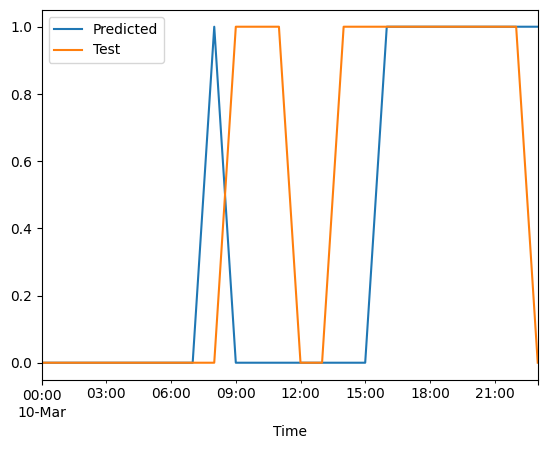

In [59]:
pd.DataFrame({'Predicted': model_rf.predict(X_test_rf), 'Test': y_test_rf}).plot()

<Axes: xlabel='Time'>

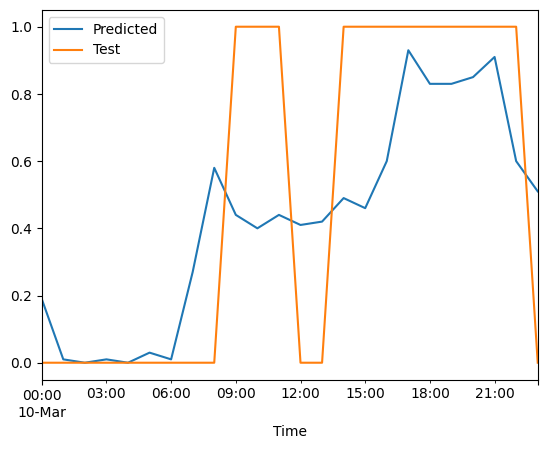

In [60]:
pd.DataFrame({'Predicted': model_rf.predict_proba(X_test_rf)[:,1], 'Test': y_test_rf}).plot()

### Model explanation

In [61]:
# Use LIME to understand the prediction for 2015-03-10 (test day) at 20:00. What can you conclude?

In [62]:
categorical_indices_rf = [
    'Usage yesterday', 	
    'hour', 	
    'weekday', 	
    'Activity 24h before', 	
    'Usage 24h before']

In [63]:
from lime import lime_tabular

lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_rf.values,
    feature_names=X_train_rf.columns,
    categorical_features=categorical_indices_rf,
    mode='classification'
)

c:\Users\piete\anaconda3\envs\machinelearning_for_socio_tech\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


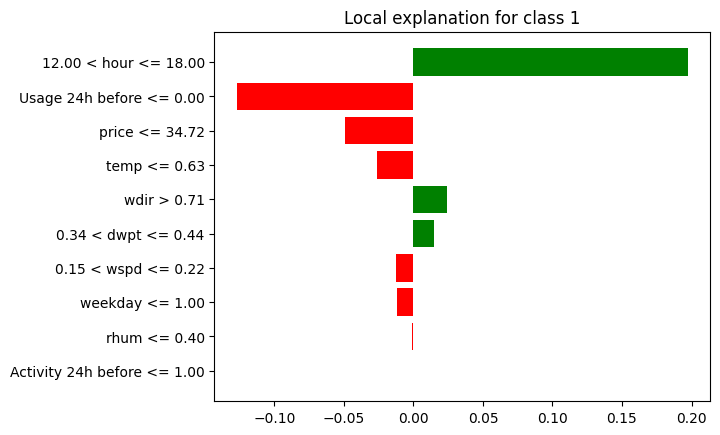

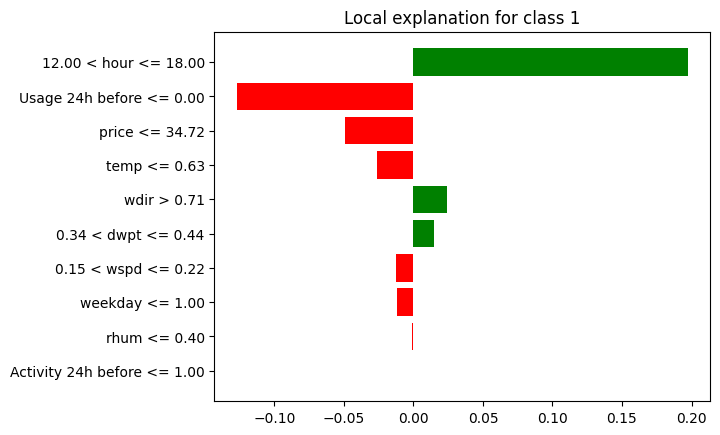

In [64]:
instance_to_explain = X_test_rf.loc['2015-03-10 14:00'].values
explanation = lime_explainer.explain_instance(
    data_row=instance_to_explain,
    predict_fn=model_rf.predict_proba,
)

explanation.as_pyplot_figure()

c:\Users\piete\anaconda3\envs\machinelearning_for_socio_tech\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


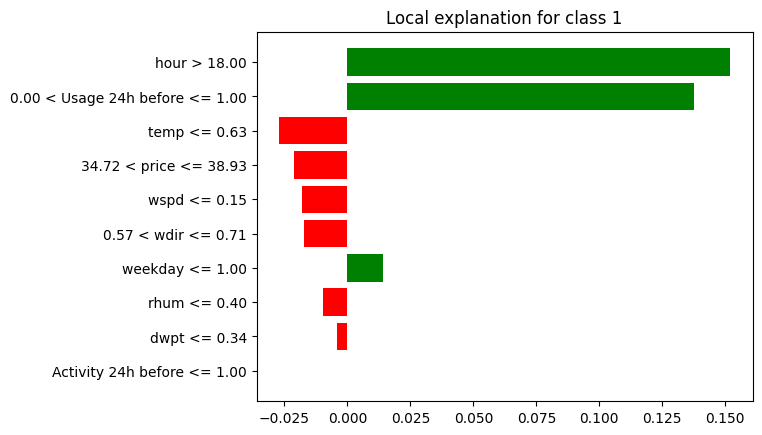

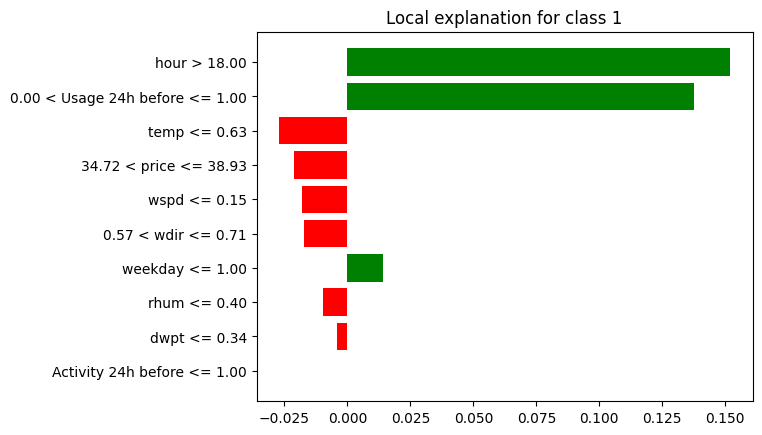

In [66]:
instance_to_explain = X_test_rf.loc['2015-03-10 20:00'].values
explanation = lime_explainer.explain_instance(
    data_row=instance_to_explain,
    predict_fn=model_rf.predict_proba,
)

explanation.as_pyplot_figure()

# major drivers for predicting television usage at 8pm are evening and usage in the previous day.

In [67]:
# Compute the SHAP values for the 24 hours of the test dataset with a KernelExplainer.
# Use a 100 sample of the train dataset as background dataset.
# Slice the SHAP matrix returned by calling the explainer to get only values for classifying a positive prediction of television activity (class = 1).

In [68]:
import shap
X100_rf = shap.sample(X_train_rf, 100, random_state=0)
explainer_rf = shap.KernelExplainer(model_rf.predict_proba, X100_rf)
shap_values_rf = explainer_rf(X_test_rf)[:,:,1]

  0%|          | 0/24 [00:00<?, ?it/s]

In [69]:
# Plot the SHAP values for each feature and test sample

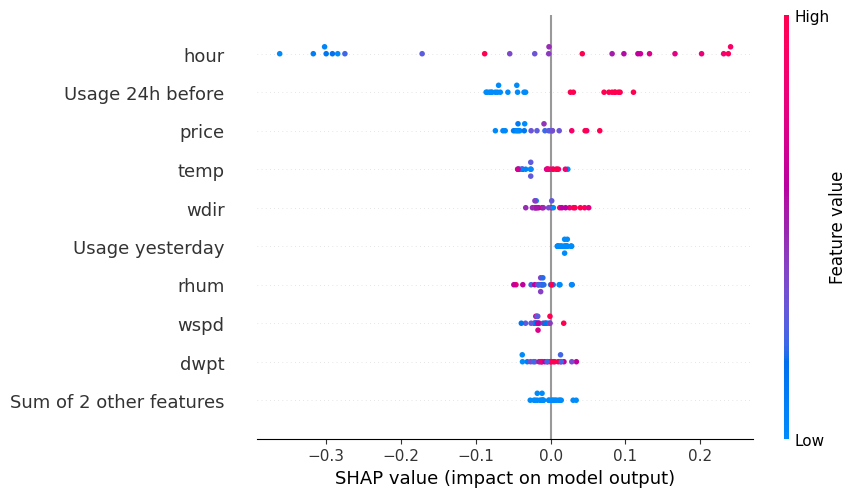

In [70]:
shap.plots.beeswarm(shap_values_rf)

In [71]:
# What are the 3 most predictive features?

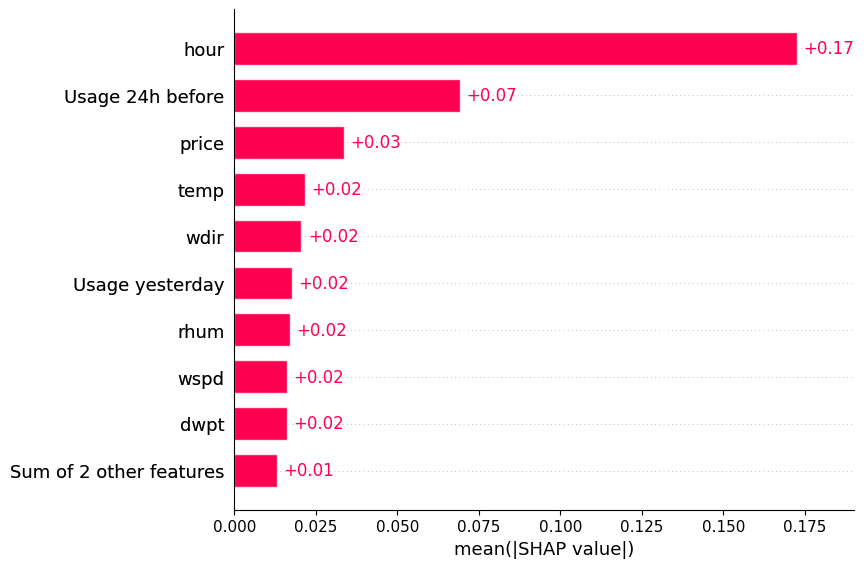

In [72]:
shap.plots.bar(shap_values_rf)

In [73]:
# Explain the 14:00 and 20:00 prediction of the test day. How could you interpret the difference? Comment also on the comparison with what found with LIME.

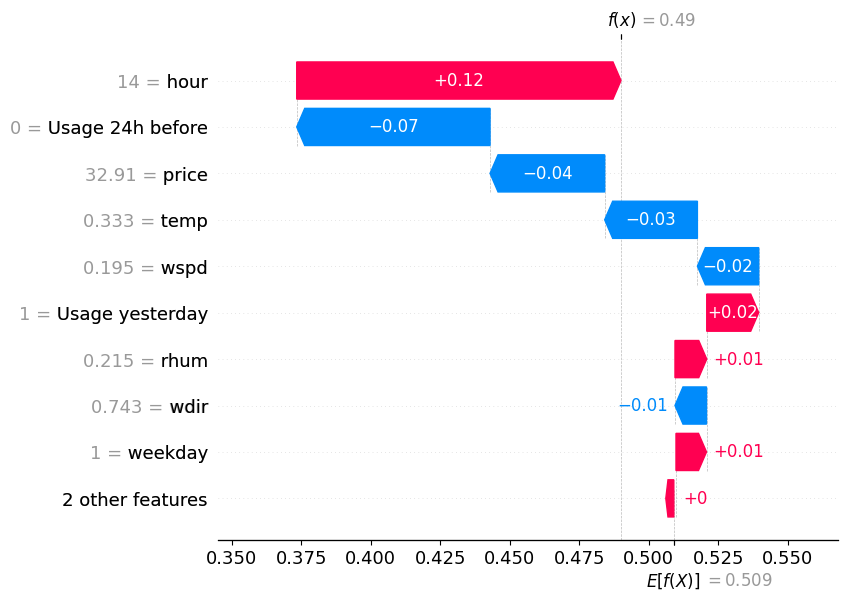

In [74]:
shap.plots.waterfall(shap_values_rf[14])

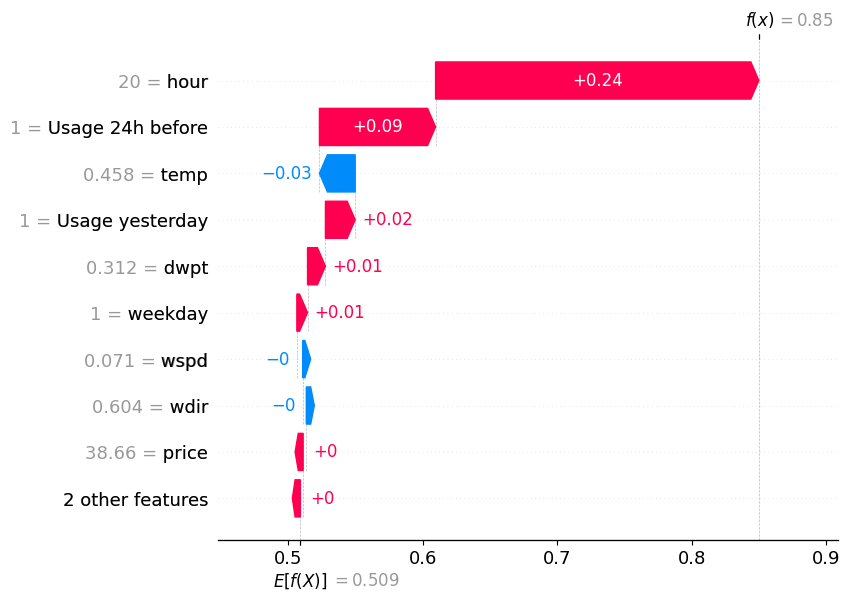

In [75]:
# Hour explains activity at 20:00 the most, likely as a fixed-hour habitual behavior.
# Good/bad weather (<-> temperature) and overall electricity demand (<-> price) more likely to affect behavior at mid-afternoon.
# LIME gives similar results, suggesting robust results and an underlying good local approx by linear model
shap.plots.waterfall(shap_values_rf[20])

In [76]:
# In what hours is the expected probability of watching television highest, across the train dataset? 
# Hint: use a partial dependence plot

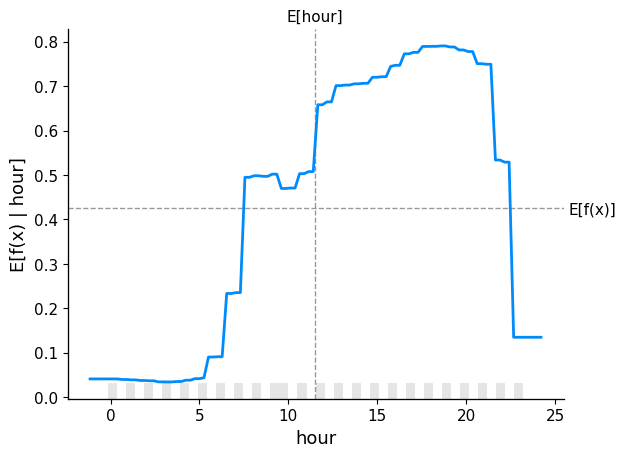

In [77]:
fig, ax = shap.partial_dependence_plot(
    "hour",
    model_rf.predict,
    X_train_rf,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ice=False,
)

In [78]:
# Compare the partial dependence plot of expected probability of watching television (y-axis) by hour (x-axis) with
# a scatter plot of SHAP values (y-axis) for the 24 hours test samples, by hour (x-axis).
# Comment on their similarity/difference.

# Hint: use shap.plots.scatter for the latter

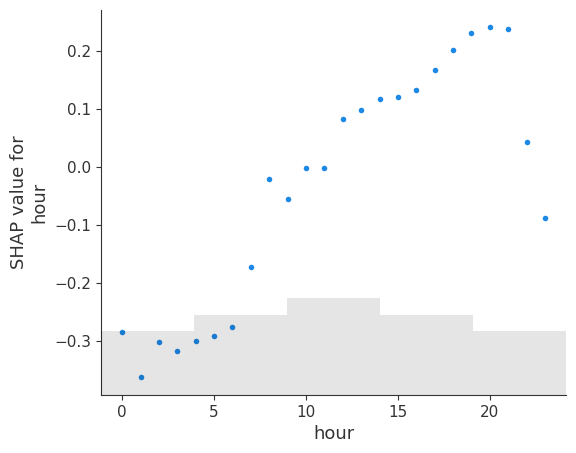

In [79]:
# PDP shows effect of individually changing hour.
# SHAP values show effect of changing hour on changing the predicted probability
# of watching TV in combination with other features for the samples considered.
shap.plots.scatter(shap_values_rf[:,'hour'])

In [80]:
# What is the expected probability of watching television given the electricity price throughout the train dataset?
# How could one interpret this relationship?

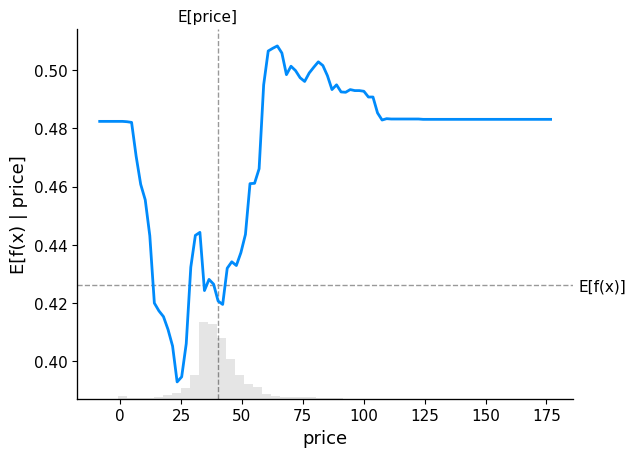

In [ ]:
# High-demand period -> higher price -> higher likelihood of using appliances including television
# Pick up some other periods
fig, ax = shap.partial_dependence_plot(
    "price",
    model_rf.predict,
    X_train_rf,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ice=False,
)

### Reflections

In [82]:
# What strategies could you use to improve the accuracy of predicting TV usage? What are the implications for interpretability?

In [83]:
# Cross-validation instead of 1 train set 1 test.
# Hypertuning.
# More complex models -> possibly higher accuracy but lower interpretability.

In [84]:
# What could be the benefits to a user of a XAI-informed model for predicting appliances usage? What could be the risks?

In [85]:
# Benefits: more aware of where demand more flexible (e.g. less hour-dependent) to take advantage of renewables / price sensitivity.
# Risks: privacy concerns.